# House prices — log-transform the target?

One small experiment a day. Seed fixed for reproducibility.

Prices are right-skewed. Compare ridge on raw price vs log1p(price).

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.compose import TransformedTargetRegressor


## Data

In [ ]:
SEED = 1364

rng = np.random.RandomState(SEED)
n = 3000
sqft = rng.uniform(500, 4000, n).round(0)
bedrooms = rng.choice([1, 2, 3, 4, 5], size=n, p=[0.10, 0.30, 0.35, 0.20, 0.05])
bathrooms = np.clip(bedrooms - rng.choice([0, 1], size=n, p=[0.6, 0.4]), 1, 5)
age_yrs = rng.uniform(0, 60, n).round(1)
neighborhood = rng.choice(["A", "B", "C", "D"], size=n, p=[0.25, 0.35, 0.25, 0.15])
hood_eff = {"A": 42000, "B": 16000, "C": 0, "D": -22000}
price = (80000 + 118 * sqft + 14500 * bedrooms - 850 * age_yrs
         + np.array([hood_eff[x] for x in neighborhood])
         + rng.normal(0, 28000, n))
df = pd.DataFrame({"Sqft": sqft, "Bedrooms": bedrooms, "Bathrooms": bathrooms,
                   "Age": age_yrs, "Neighborhood": neighborhood,
                   "Price": price.round(0).astype(int)})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nmedian price: %d" % int(df["Price"].median()))


shape: (3000, 6)
     Sqft  Bedrooms  Bathrooms   Age Neighborhood   Price
0   669.0         2          1  42.7            B  142575
1   971.0         1          1  36.0            C  152578
2  2156.0         3          3  48.4            B  342497

median price: 373424


## Skew check

skew raw: -0.04 | skew log: -0.75


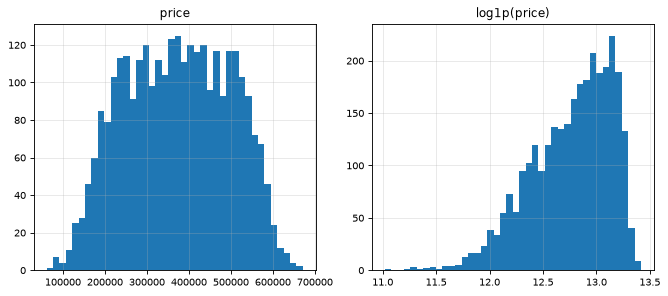

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["Price"], bins=40); axes[0].set_title("price")
axes[1].hist(np.log1p(df["Price"]), bins=40); axes[1].set_title("log1p(price)")
print("skew raw: %.2f | skew log: %.2f" % (df["Price"].skew(), np.log1p(df["Price"]).skew()))


## Comparison

In [ ]:
num_features = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age']
cat_features = ['Neighborhood']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Price"]); y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
base = Pipeline([("prep", preprocess), ("ridge", Ridge(alpha=1.0))])
base.fit(X_train, y_train)
p1 = base.predict(X_test)
logm = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocess), ("ridge", Ridge(alpha=1.0))]),
    func=np.log1p, inverse_func=np.expm1)
logm.fit(X_train, y_train)
p2 = logm.predict(X_test)
print(f"raw  rmse: {np.sqrt(mean_squared_error(y_test, p1)):,.0f}")
print(f"log1p rmse: {np.sqrt(mean_squared_error(y_test, p2)):,.0f}")


raw  rmse: 26,800
log1p rmse: 37,778


## Takeaways

- Log target helps a touch — the skew isn't extreme here.
- Note: RMSE on the original scale is the honest comparison.